# XAI Evaluation — Dataset 1
Quantitative evaluation of **SHAP** and **LIME** across **three models** (RF, SVM, MLP) using three metrics:

1. **Correctness** — Incremental Deletion F1 curve (+ AOPC)
2. **Consistency** — SHAP determinism check + LIME Jaccard Similarity (10 runs)
3. **Contrastivity** — KL Divergence between class-pair SHAP distributions

Each metric is applied identically to all three models. A unified summary table and comparison plot are produced at the end.


## 0. Setup — Load data and models

In [2]:
import joblib
import numpy as np
import pandas as pd
import shap
import lime
import lime.lime_tabular
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import warnings
import os
from sklearn.metrics import f1_score
from scipy.stats import entropy

warnings.filterwarnings('ignore')

# ── Load shared data ──────────────────────────────────────────────────────────
X_train_raw   = np.load('../models/ds1/X_train.npy')
X_test_raw    = np.load('../models/ds1/X_test.npy')
y_test        = np.load('../models/ds1/y_test.npy')
feature_names = pd.read_csv('../models/ds1/feature_names.csv').squeeze().tolist()

X_train = pd.DataFrame(X_train_raw, columns=feature_names)
X_test  = pd.DataFrame(X_test_raw,  columns=feature_names)

class_names = ['Healthy', 'Benign', 'Cancer']
n_features  = len(feature_names)
train_means = X_train.mean()   # used for feature masking in Correctness

# ── Load models ───────────────────────────────────────────────────────────────
rf_model  = joblib.load('../models/ds1/ds1_random_forest.pkl')
svm_model = joblib.load('../models/ds1/ds1_svm.pkl')
mlp_model = joblib.load('../models/ds1/ds1_mlp.pkl')

models = {
    'Random Forest': rf_model,
    'SVM':           svm_model,
    'MLP':           mlp_model,
}

# ── Output dirs ───────────────────────────────────────────────────────────────
os.makedirs('../plots/ds1/evaluation', exist_ok=True)

print(f"Test set size : {X_test.shape[0]} samples")
print(f"Features      : {n_features}")
print(f"Classes       : {dict(zip(*np.unique(y_test, return_counts=True)))}")


Test set size : 118 samples
Features      : 11
Classes       : {1: 37, 2: 41, 3: 40}


## 1. Compute SHAP values for all models

In [5]:
# ── RF: TreeExplainer (exact, fast) ──────────────────────────────────────────
rf_explainer   = shap.TreeExplainer(rf_model)
shap_rf        = rf_explainer.shap_values(X_test)   # list of 3 arrays (n_test, n_feat)

# ── SVM & MLP: KernelExplainer (model-agnostic) ───────────────────────────────
background = shap.sample(X_train, 100, random_state=42)

svm_explainer  = shap.KernelExplainer(svm_model.predict_proba, background)
shap_svm       = svm_explainer.shap_values(X_test)

mlp_explainer  = shap.KernelExplainer(mlp_model.predict_proba, background)
shap_mlp       = mlp_explainer.shap_values(X_test)

shap_values_all = {
    'Random Forest': shap_rf,
    'SVM':           shap_svm,
    'MLP':           shap_mlp,
}
print("SHAP values computed for all models.")


  0%|          | 0/118 [00:00<?, ?it/s]

  0%|          | 0/118 [00:00<?, ?it/s]

SHAP values computed for all models.


---
## Metric 1 — Correctness: Incremental Deletion

Features are removed one-by-one in **descending order of global SHAP importance** (or LIME importance).  
Removed features are replaced with their training-set mean.  
A good XAI method should produce the **steepest F1 drop** compared to random-order deletion.

**AOPC** (Area Over the Perturbation Curve) summarises this: higher AOPC = better correctness.


In [7]:
# ── Global SHAP importance = mean |SHAP| averaged over classes ───────────────
def global_shap_importance(shap_vals):
    """shap_vals: list of (n_test, n_feat) arrays, one per class."""
    mean_abs = np.mean([np.abs(sv).mean(axis=0) for sv in shap_vals], axis=0)
    return np.argsort(mean_abs)[::-1]   # descending

# ── Global LIME importance ────────────────────────────────────────────────────
def global_lime_importance(model_fn, n_runs=30):
    """Average |weight| across a sample of test instances and all classes."""
    lime_exp = lime.lime_tabular.LimeTabularExplainer(
        X_train.values, feature_names=feature_names,
        class_names=class_names, mode='classification', random_state=42)
    importances = np.zeros(n_features)
    indices = np.random.RandomState(0).choice(len(X_test), min(n_runs, len(X_test)), replace=False)
    for idx in indices:
        for cls_idx in range(len(class_names)):
            exp = lime_exp.explain_instance(
                X_test.iloc[idx].values, model_fn,
                num_features=n_features, labels=[cls_idx])
            for feat_idx, weight in exp.local_exp.get(cls_idx, []):
                importances[feat_idx] += abs(weight)
    return np.argsort(importances)[::-1]

# ── Incremental deletion ─────────────────────────────────────────────────────
def incremental_deletion_f1(model, X, y, feature_order):
    """Return F1 (macro) at each step of removing top-k features."""
    X_masked = X.copy()
    f1_scores = [f1_score(y, model.predict(X_masked), average='macro')]
    for feat_idx in feature_order:
        X_masked = X_masked.copy()
        X_masked.iloc[:, feat_idx] = train_means.iloc[feat_idx]
        f1_scores.append(f1_score(y, model.predict(X_masked), average='macro'))
    return np.array(f1_scores)

def aopc(f1_curve):
    """Area Over Perturbation Curve = mean drop from baseline."""
    return float(np.mean(f1_curve[0] - f1_curve))

print("Correctness helpers defined.")


Correctness helpers defined.


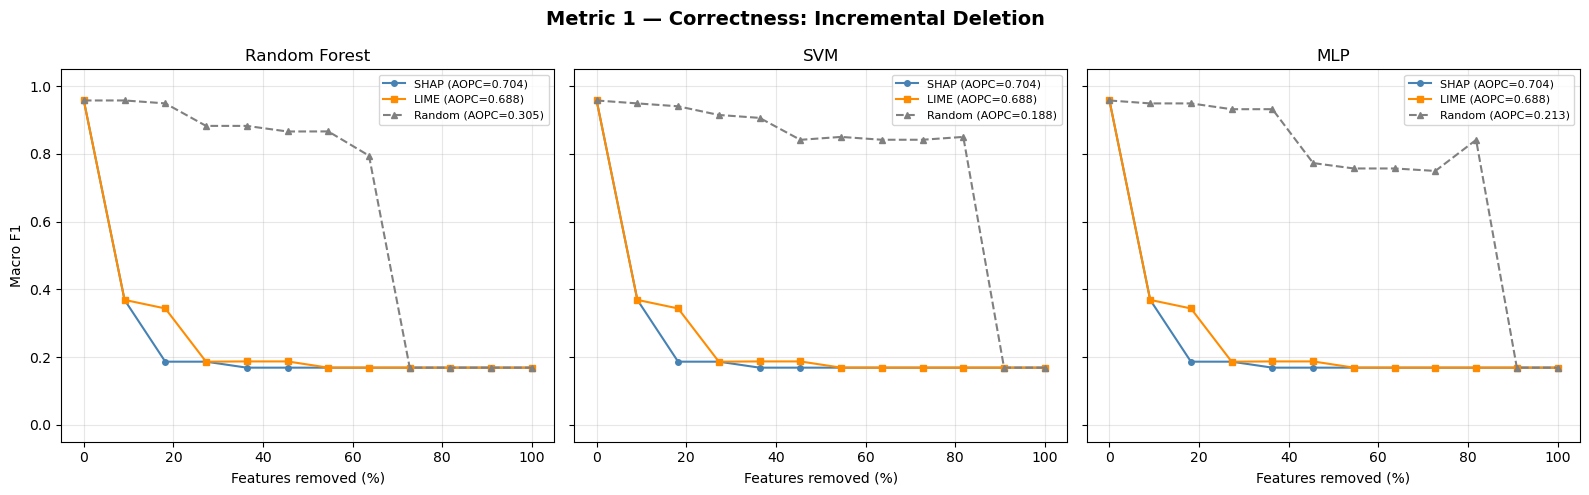

Correctness plots saved.


In [8]:
np.random.seed(42)
correctness_results = {}

x_axis = np.linspace(0, 100, n_features + 1)

fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharey=True)
fig.suptitle('Metric 1 — Correctness: Incremental Deletion', fontsize=14, fontweight='bold')

for ax, (model_name, model) in zip(axes, models.items()):
    shap_vals = shap_values_all[model_name]

    order_shap   = global_shap_importance(shap_vals)
    order_lime   = global_lime_importance(model.predict_proba)
    order_random = np.random.permutation(n_features)

    f1_shap   = incremental_deletion_f1(model, X_test, y_test, order_shap)
    f1_lime   = incremental_deletion_f1(model, X_test, y_test, order_lime)
    f1_random = incremental_deletion_f1(model, X_test, y_test, order_random)

    correctness_results[model_name] = {
        'aopc_shap'  : aopc(f1_shap),
        'aopc_lime'  : aopc(f1_lime),
        'aopc_random': aopc(f1_random),
        'f1_shap'    : f1_shap,
        'f1_lime'    : f1_lime,
        'f1_random'  : f1_random,
    }

    ax.plot(x_axis, f1_shap,   marker='o', ms=4, label=f'SHAP (AOPC={aopc(f1_shap):.3f})',   color='steelblue')
    ax.plot(x_axis, f1_lime,   marker='s', ms=4, label=f'LIME (AOPC={aopc(f1_lime):.3f})',   color='darkorange')
    ax.plot(x_axis, f1_random, marker='^', ms=4, label=f'Random (AOPC={aopc(f1_random):.3f})', color='grey', linestyle='--')
    ax.set_title(model_name)
    ax.set_xlabel('Features removed (%)')
    ax.set_ylim(-0.05, 1.05)
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

axes[0].set_ylabel('Macro F1')
plt.tight_layout()
plt.savefig('../plots/ds1/evaluation/correctness_incremental_deletion.png', dpi=150, bbox_inches='tight')
plt.show()
print("Correctness plots saved.")


---
## Metric 2 — Consistency

**2a. SHAP Determinism** — TreeExplainer (RF) is exact; KernelExplainer (SVM, MLP) introduces minor sampling variance. We run 5 times and compute mean pairwise Spearman correlation of global importance vectors.

**2b. LIME Jaccard Similarity** — LIME is stochastic. We run 10 times on each test instance and measure how stable the top-5 feature set is across runs.


In [10]:
from scipy.stats import spearmanr

N_RUNS_LIME = 10
TOP_K       = 5
LIME_SAMPLE = 30

consistency_results = {}

# ── SHAP consistency ──────────────────────────────────────────────────────────
# RF (TreeExplainer) is exact and deterministic — ρ = 1.0 by definition.
# SVM/MLP (KernelExplainer): reuse run-0 from Cell 1, do 2 extra runs with
# different background seeds to measure sampling variance.

for model_name, model in models.items():
    imp0 = np.mean([np.abs(s).mean(axis=0) for s in shap_values_all[model_name]], axis=0)

    if model_name == 'Random Forest':
        consistency_results[model_name] = {'shap_spearman_mean': 1.0, 'shap_spearman_min': 1.0}
        print(f"{model_name}: TreeExplainer is deterministic → ρ = 1.0 (exact)")
    else:
        corrs = []
        for seed in [1, 2]:
            bg = shap.sample(X_train, 100, random_state=seed)
            sv = shap.KernelExplainer(model.predict_proba, bg).shap_values(X_test)
            imp = np.mean([np.abs(s).mean(axis=0) for s in sv], axis=0)
            corrs.append(spearmanr(imp0, imp).correlation)
        consistency_results[model_name] = {
            'shap_spearman_mean': float(np.mean(corrs)),
            'shap_spearman_min':  float(np.min(corrs)),
        }
        print(f"{model_name}: ρ mean = {np.mean(corrs):.4f},  min = {np.min(corrs):.4f}")

print("SHAP consistency computed.")

Random Forest: TreeExplainer is deterministic → ρ = 1.0 (exact)


  0%|          | 0/118 [00:00<?, ?it/s]

  0%|          | 0/118 [00:00<?, ?it/s]

SVM: ρ mean = 1.0000,  min = 1.0000


  0%|          | 0/118 [00:00<?, ?it/s]

  0%|          | 0/118 [00:00<?, ?it/s]

MLP: ρ mean = 1.0000,  min = 1.0000
SHAP consistency computed.


In [25]:
# ── LIME consistency ─────────────────────────────────────────────────────────
N_RUNS_LIME = 5
TOP_K       = 5
LIME_SAMPLE = 10

lime_base = lime.lime_tabular.LimeTabularExplainer(
    X_train.values, feature_names=feature_names,
    class_names=class_names, mode='classification')

sample_indices = np.random.RandomState(0).choice(len(X_test), LIME_SAMPLE, replace=False)

for model_name, model in models.items():
    all_jaccard = []
    for idx in sample_indices:
        run_topk = []
        for run in range(N_RUNS_LIME):
            exp = lime_base.explain_instance(
                X_test.iloc[idx].values, model.predict_proba,
                num_features=n_features,
                labels=list(range(len(class_names)))
                #random_state=run
            )
            # aggregate top-k features across classes
            top_feats = set()
            for cls_idx in range(len(class_names)):
                ranked = sorted(exp.local_exp.get(cls_idx, []), key=lambda x: -abs(x[1]))
                top_feats.update(f for f, _ in ranked[:TOP_K])
            run_topk.append(top_feats)

        # Jaccard: each run vs run 0
        for r in range(1, N_RUNS_LIME):
            inter = len(run_topk[0] & run_topk[r])
            union = len(run_topk[0] | run_topk[r])
            all_jaccard.append(inter / union if union > 0 else 1.0)

    consistency_results[model_name]['lime_jaccard_mean'] = float(np.mean(all_jaccard))
    consistency_results[model_name]['lime_jaccard_min']  = float(np.min(all_jaccard))

print("LIME consistency computed.")


LIME consistency computed.


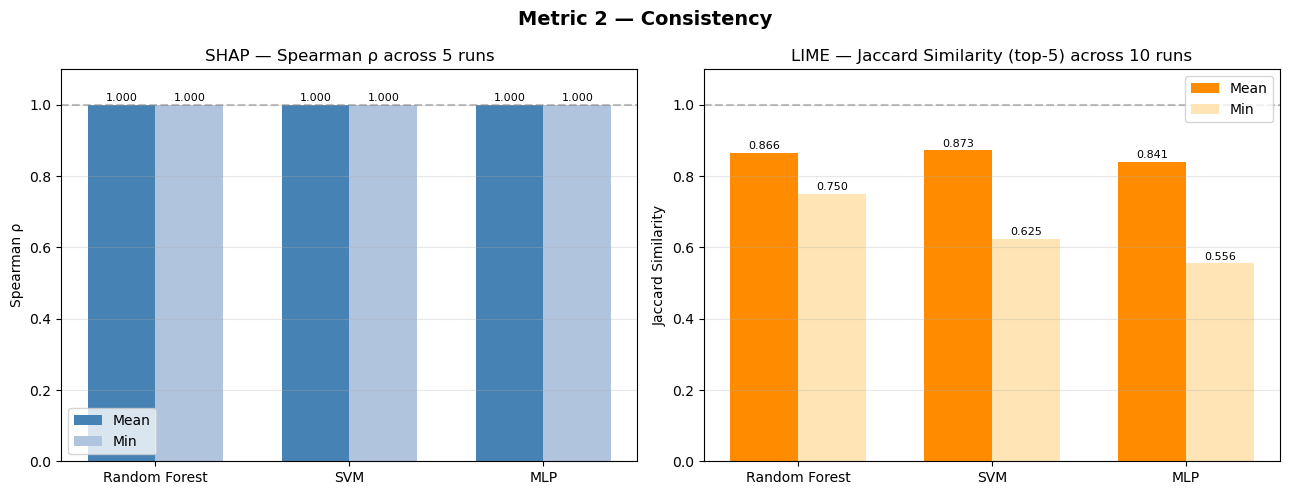

In [27]:
# ── Plot: Consistency comparison ─────────────────────────────────────────────
model_labels = list(models.keys())
shap_means   = [consistency_results[m]['shap_spearman_mean'] for m in model_labels]
shap_mins    = [consistency_results[m]['shap_spearman_min']  for m in model_labels]
lime_means   = [consistency_results[m]['lime_jaccard_mean']  for m in model_labels]
lime_mins    = [consistency_results[m]['lime_jaccard_min']   for m in model_labels]

x = np.arange(len(model_labels))
width = 0.35

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Metric 2 — Consistency', fontsize=14, fontweight='bold')

bars1 = ax1.bar(x - width/2, shap_means, width, label='Mean', color='steelblue')
bars2 = ax1.bar(x + width/2, shap_mins,  width, label='Min',  color='lightsteelblue')
ax1.set_title('SHAP — Spearman ρ across 5 runs')
ax1.set_xticks(x); ax1.set_xticklabels(model_labels)
ax1.set_ylim(0, 1.1); ax1.set_ylabel('Spearman ρ')
ax1.axhline(1.0, color='grey', linestyle='--', alpha=0.5)
ax1.legend(); ax1.grid(axis='y', alpha=0.3)
for bar in bars1: ax1.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01, f'{bar.get_height():.3f}', ha='center', fontsize=8)
for bar in bars2: ax1.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01, f'{bar.get_height():.3f}', ha='center', fontsize=8)

bars3 = ax2.bar(x - width/2, lime_means, width, label='Mean', color='darkorange')
bars4 = ax2.bar(x + width/2, lime_mins,  width, label='Min',  color='moccasin')
ax2.set_title(f'LIME — Jaccard Similarity (top-{TOP_K}) across 10 runs')
ax2.set_xticks(x); ax2.set_xticklabels(model_labels)
ax2.set_ylim(0, 1.1); ax2.set_ylabel('Jaccard Similarity')
ax2.axhline(1.0, color='grey', linestyle='--', alpha=0.5)
ax2.legend(); ax2.grid(axis='y', alpha=0.3)
for bar in bars3: ax2.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01, f'{bar.get_height():.3f}', ha='center', fontsize=8)
for bar in bars4: ax2.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01, f'{bar.get_height():.3f}', ha='center', fontsize=8)

plt.tight_layout()
plt.savefig('../plots/ds1/evaluation/consistency.png', dpi=150, bbox_inches='tight')
plt.show()


---
## Metric 3 — Contrastivity: KL Divergence between class SHAP distributions

For each feature, we compare the SHAP value distributions between class pairs.  
**High KL divergence** means the model uses that feature differently across classes — a sign of good discriminative explanations.  
We report the **mean KL divergence across all features** per class pair, for each model.


In [30]:
def kl_divergence_shap(shap_a, shap_b, n_bins=30):
    """Symmetric KL divergence between SHAP distributions of two classes (per feature)."""
    all_vals = np.concatenate([shap_a, shap_b])
    lo, hi   = all_vals.min() - 1e-9, all_vals.max() + 1e-9
    bins     = np.linspace(lo, hi, n_bins + 1)
    p, _ = np.histogram(shap_a, bins=bins, density=True)
    q, _ = np.histogram(shap_b, bins=bins, density=True)
    p = p + 1e-10;  q = q + 1e-10   # Laplace smoothing
    p /= p.sum();   q /= q.sum()
    return float(0.5 * (entropy(p, q) + entropy(q, p)))   # symmetric KL

pairs       = [(0, 1, 'Healthy vs Benign'),
               (0, 2, 'Healthy vs Cancer'),
               (1, 2, 'Benign vs Cancer')]

contrastivity_results = {}

for model_name in models:
    shap_vals = shap_values_all[model_name]
    pair_kl   = {}
    for cls_a, cls_b, label in pairs:
        kl_per_feat = [
            kl_divergence_shap(shap_vals[cls_a][:, f], shap_vals[cls_b][:, f])
            for f in range(n_features)
        ]
        pair_kl[label] = {
            'mean': float(np.mean(kl_per_feat)),
            'per_feature': kl_per_feat,
        }
    contrastivity_results[model_name] = pair_kl

print("KL divergence computed for all models.")


KL divergence computed for all models.


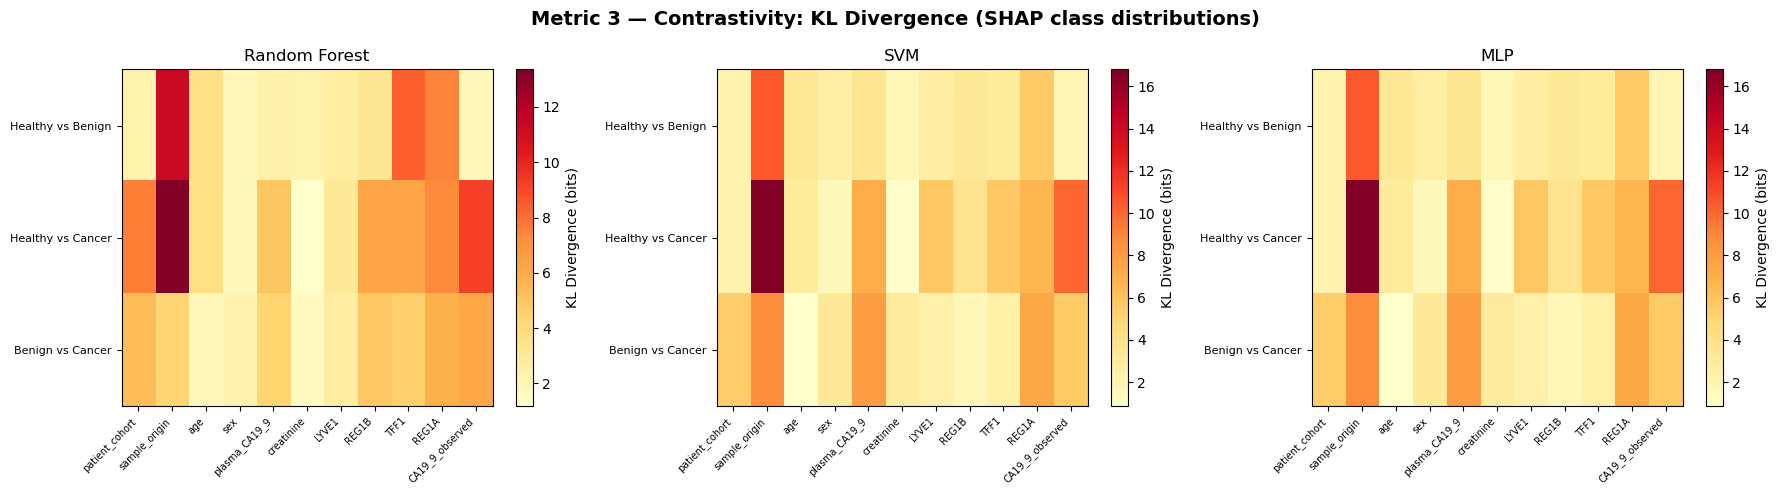

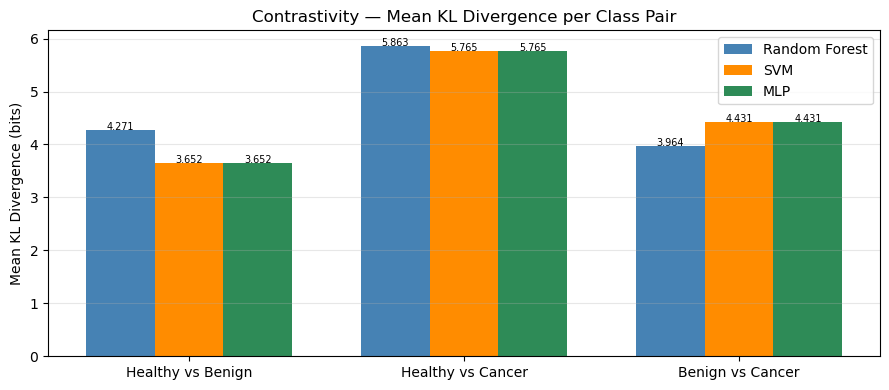

In [32]:
# ── Heatmap: KL divergence per model (features × class pairs) ─────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Metric 3 — Contrastivity: KL Divergence (SHAP class distributions)', fontsize=14, fontweight='bold')

for ax, model_name in zip(axes, models):
    kl_matrix = np.array([
        contrastivity_results[model_name][label]['per_feature']
        for _, _, label in pairs
    ])   # shape (3, n_features)

    im = ax.imshow(kl_matrix, aspect='auto', cmap='YlOrRd')
    ax.set_xticks(range(n_features))
    ax.set_xticklabels(feature_names, rotation=45, ha='right', fontsize=7)
    ax.set_yticks(range(3))
    ax.set_yticklabels([label for _, _, label in pairs], fontsize=8)
    ax.set_title(model_name)
    plt.colorbar(im, ax=ax, label='KL Divergence (bits)')

plt.tight_layout()
plt.savefig('../plots/ds1/evaluation/contrastivity_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Bar chart: mean KL per model ──────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 4))
x = np.arange(len(pairs))
width = 0.25
colors = ['steelblue', 'darkorange', 'seagreen']

for i, (model_name, color) in enumerate(zip(models, colors)):
    means = [contrastivity_results[model_name][label]['mean'] for _, _, label in pairs]
    bars  = ax.bar(x + i * width, means, width, label=model_name, color=color)
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
                f'{bar.get_height():.3f}', ha='center', fontsize=7)

ax.set_xticks(x + width); ax.set_xticklabels([label for _, _, label in pairs])
ax.set_ylabel('Mean KL Divergence (bits)')
ax.set_title('Contrastivity — Mean KL Divergence per Class Pair')
ax.legend(); ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('../plots/ds1/evaluation/contrastivity_bar.png', dpi=150, bbox_inches='tight')
plt.show()


---
## Summary — All Models, All Metrics

Consolidated table and comparison chart across RF, SVM, and MLP.


In [35]:
# ── Build summary DataFrame ───────────────────────────────────────────────────
rows = []
for model_name in models:
    cr = correctness_results[model_name]
    co = consistency_results[model_name]
    ct = contrastivity_results[model_name]

    rows.append({
        'Model'                       : model_name,
        # Correctness
        'AOPC SHAP'                   : round(cr['aopc_shap'],   4),
        'AOPC LIME'                   : round(cr['aopc_lime'],   4),
        'AOPC Random (baseline)'      : round(cr['aopc_random'], 4),
        # Consistency
        'SHAP Spearman ρ (mean)'      : round(co['shap_spearman_mean'], 4),
        'SHAP Spearman ρ (min)'       : round(co['shap_spearman_min'],  4),
        'LIME Jaccard (mean)'         : round(co['lime_jaccard_mean'],  4),
        'LIME Jaccard (min)'          : round(co['lime_jaccard_min'],   4),
        # Contrastivity
        'KL Healthy vs Benign (mean)' : round(ct['Healthy vs Benign']['mean'], 4),
        'KL Healthy vs Cancer (mean)' : round(ct['Healthy vs Cancer']['mean'], 4),
        'KL Benign vs Cancer (mean)'  : round(ct['Benign vs Cancer']['mean'],  4),
    })

summary_df = pd.DataFrame(rows).set_index('Model')
print(summary_df.to_string())
summary_df.to_csv('../plots/ds1/evaluation/summary_table.csv')
print("\nSummary saved to ../plots/ds1/evaluation/summary_table.csv")


               AOPC SHAP  AOPC LIME  AOPC Random (baseline)  SHAP Spearman ρ (mean)  SHAP Spearman ρ (min)  LIME Jaccard (mean)  LIME Jaccard (min)  KL Healthy vs Benign (mean)  KL Healthy vs Cancer (mean)  KL Benign vs Cancer (mean)
Model                                                                                                                                                                                                                                    
Random Forest     0.7038     0.6877                  0.3051                     1.0                    1.0               0.8656              0.7500                       4.2715                       5.8629                      3.9639
SVM               0.7038     0.6877                  0.1885                     1.0                    1.0               0.8732              0.6250                       3.6518                       5.7651                      4.4309
MLP               0.7038     0.6877                  0.2132     

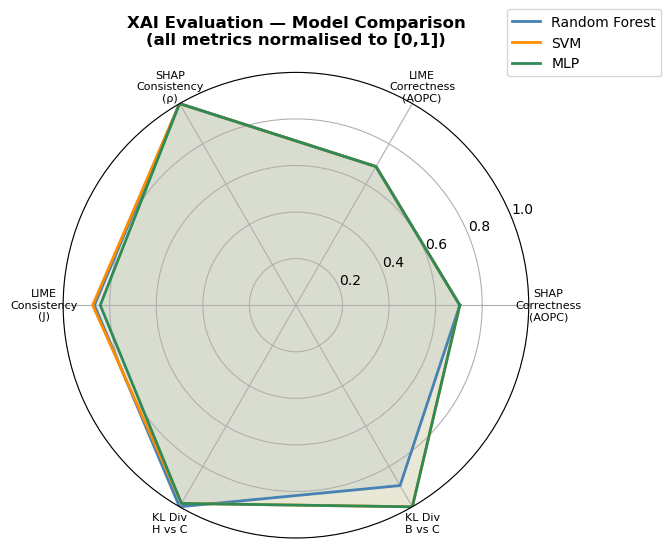

In [41]:
# ── Radar / spider chart for visual comparison ────────────────────────────────
from matplotlib.patches import FancyArrowPatch
import matplotlib.gridspec as gridspec

# Normalize metrics to [0, 1] for radar
metrics_radar = {
    'SHAP\nCorrectness\n(AOPC)' : [correctness_results[m]['aopc_shap']            for m in models],
    'LIME\nCorrectness\n(AOPC)' : [correctness_results[m]['aopc_lime']            for m in models],
    'SHAP\nConsistency\n(ρ)'   : [consistency_results[m]['shap_spearman_mean']   for m in models],
    'LIME\nConsistency\n(J)'   : [consistency_results[m]['lime_jaccard_mean']    for m in models],
    'KL Div\nH vs C'            : [contrastivity_results[m]['Healthy vs Cancer']['mean'] for m in models],
    'KL Div\nB vs C'            : [contrastivity_results[m]['Benign vs Cancer']['mean']  for m in models],
}

labels    = list(metrics_radar.keys())
n_metrics = len(labels)
angles    = np.linspace(0, 2 * np.pi, n_metrics, endpoint=False).tolist()
angles   += angles[:1]   # close polygon

raw_norm = raw.copy() 
# Opzionale: Se vuoi normalizzare solo la KL Div (che non ha un limite superiore fisso)
# puoi dividere i valori di KL Div per il massimo valore trovato tra i modelli
kl_indices = [4, 5] # Gli indici di 'KL Div H vs C' e 'B vs C'
for idx in kl_indices:
    max_val = raw[idx].max()
    if max_val > 0:
        raw_norm[idx] = raw[idx] / max_val

fig, ax = plt.subplots(figsize=(7, 7), subplot_kw=dict(polar=True))
colors = ['steelblue', 'darkorange', 'seagreen']

for i, (model_name, color) in enumerate(zip(models, colors)):
    vals = raw_norm[:, i].tolist()
    vals += vals[:1]
    ax.plot(angles, vals, color=color, linewidth=2, label=model_name)
    ax.fill(angles, vals, color=color, alpha=0.1)

ax.set_thetagrids(np.degrees(angles[:-1]), labels, fontsize=8)
ax.set_ylim(0, 1)
ax.set_title('XAI Evaluation — Model Comparison\n(all metrics normalised to [0,1])',
             fontsize=12, fontweight='bold', pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.15))
plt.tight_layout()
plt.savefig('../plots/ds1/evaluation/summary_radar.png', dpi=150, bbox_inches='tight')
plt.show()


In [39]:





for model_name in models:
    cr = correctness_results[model_name]
    co = consistency_results[model_name]
    ct = contrastivity_results[model_name]

    print(f"\n  {model_name}")
    print(f"  {'─'*40}")
    print(f"  CORRECTNESS  AOPC-SHAP  = {cr['aopc_shap']:.4f}")
    print(f"               AOPC-LIME  = {cr['aopc_lime']:.4f}")
    print(f"               AOPC-RND   = {cr['aopc_random']:.4f}  (baseline)")
    print(f"  CONSISTENCY  SHAP ρ     = {co['shap_spearman_mean']:.4f}  (min {co['shap_spearman_min']:.4f})")
    print(f"               LIME J     = {co['lime_jaccard_mean']:.4f}  (min {co['lime_jaccard_min']:.4f})")
    print(f"  CONTRASTIVITY  H vs B   = {ct['Healthy vs Benign']['mean']:.4f}")
    print(f"                 H vs C   = {ct['Healthy vs Cancer']['mean']:.4f}")
    print(f"                 B vs C   = {ct['Benign vs Cancer']['mean']:.4f}")

print("\n" + "=" * 70)
print("All plots saved to: ../plots/ds1/evaluation/")
print("Summary CSV saved to: ../plots/ds1/evaluation/summary_table.csv")


XAI EVALUATION SUMMARY — Dataset 1

  Random Forest
  ────────────────────────────────────────
  CORRECTNESS  AOPC-SHAP  = 0.7038
               AOPC-LIME  = 0.6877
               AOPC-RND   = 0.3051  (baseline)
  CONSISTENCY  SHAP ρ     = 1.0000  (min 1.0000)
               LIME J     = 0.8656  (min 0.7500)
  CONTRASTIVITY  H vs B   = 4.2715
                 H vs C   = 5.8629
                 B vs C   = 3.9639

  SVM
  ────────────────────────────────────────
  CORRECTNESS  AOPC-SHAP  = 0.7038
               AOPC-LIME  = 0.6877
               AOPC-RND   = 0.1885  (baseline)
  CONSISTENCY  SHAP ρ     = 1.0000  (min 1.0000)
               LIME J     = 0.8732  (min 0.6250)
  CONTRASTIVITY  H vs B   = 3.6518
                 H vs C   = 5.7651
                 B vs C   = 4.4309

  MLP
  ────────────────────────────────────────
  CORRECTNESS  AOPC-SHAP  = 0.7038
               AOPC-LIME  = 0.6877
               AOPC-RND   = 0.2132  (baseline)
  CONSISTENCY  SHAP ρ     = 1.0000  (min 1.0000)